# Assignment 6: Data Scraping
```
Course: ENV 700 - Environmental Data Exploration
Author: Ella Woodruff
Date: Fall 2026
```

This notebook accompanies the Python lessons on **Data Scraping**. We'll be scraping data from the North Carolina Department of Water Quality (NC DWQ). 

## 1. Setup
* Import packages: `requests`, `BeautifulSoup` (from `bs4`), `pandas` (as `pd`), `seaborn` (as `sns`) and any other packages you wish to use. 
* Set your Seaborn theme's style, context, and any runtime configurations you wish

In [1]:
#Import packages
import pandas as pd
import requests
from bs4 import BeautifulSoup
import time
from itertools import product
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
import calendar

#Set Seaborn theme
sns.set_theme(style='whitegrid', context='notebook')

## 2. Scraping Water Supply Data 
We will be scraping data from the NC DEQs Local Water Supply Planning website, specifically the Durham's 2025 Municipal Local Water Supply Plan (LWSP): 
 * Navigate to https://www.ncwater.org/WUDC/app/LWSP/search.php
 * Set the year to 2025
 * Scroll down and select the LWSP link next to Durham Municipality. 
 * Note the web address: <https://www.ncwater.org/WUDC/app/LWSP/report.php?pwsid=03-32-010&year=2025>

---
### 2.1 Retrieve the website and parse it using BeautifulSoup

In [2]:
# 2.1 Retrieve the website and parse it using BeautifulSoup
url = 'https://www.ncwater.org/WUDC/app/LWSP/report.php?pwsid=03-32-010&year=2025'

response = requests.get(url)
response.raise_for_status()

webpage = BeautifulSoup(response.text, 'html.parser')
type(webpage)

if webpage.title:
        print(webpage.title.get_text(strip=True))
else: print('No page title')

DWR :: Local Water Supply Planning


### 2.2 The data we want to collect are listed below:

* From the **1. System Information** section:
    - Water system name
    - Contact Person
    - Ownership
 
* From the **3. Water Supply Sources** section:
    - Maximum Day Use (MGD) - for each month

In the code chunk below scrape these values, assigning them to four separate variables.  
>HINT: The first value should be "`Durham`", the second "`Kieu Tran`", the third "`Municipality`", and the last should be a vector of 12 numeric values (represented as strings)".

In [3]:
# 2.2 Scrape the data into variables
the_water_system = webpage.select_one(
    'div+ table tr:nth-child(1) td:nth-child(2)'
).get_text(strip=True)
the_contact_person = webpage.select_one(
    'div+ table tr:nth-child(4) td:nth-child(2)'
).get_text(strip=True)
the_ownership = webpage.select_one('div+ table tr:nth-child(2) td:nth-child(4)').get_text(strip=True)

mgd_nodes = webpage.select('th~ td+ td')

mgd = [node.get_text(strip=True) for node in mgd_nodes]

### 2.3 Construct a dataframe from the scraped data
Convert your scraped data into a dataframe. 
* This dataframe should have a column for each of the 4 variables scraped and a row for the month corresponding to the withdrawal data. 
* Note that you won't likely be able to scrape max water usage data in chronological order.
* Include columns for the month and year the data were collected. 
* Sort the data on year and month.
* Construct a datetime column from the year and month, assuming the day of the month will be the first. 

>🔥**TIP**: : To construct a list from a repeated set of values, use this approach:
>```python
>years_x6 = [2025] * 6
>print(years_x6)
>```

>🔥**TIP**: To construct a datetime column when you just the year and month, you can use the following:
>```python
>df['Date'] = pd.to_datetime({
>    "year": df['Year'],
>    "month": df['Month'],
>    "day": 1
>})
>```

In [5]:
# 2.3 Construct the dataframe from scraped data
month_order = [1, 5, 9, 2, 6, 10, 3, 7, 11, 4, 8, 12]
years_x12 = [2025] * 12

df_use = pd.DataFrame({
    'Month':month_order,
    'Year':years_x12,
    "Max_MGD": pd.to_numeric(mgd)  
})


df_use['Date'] = pd.to_datetime({
    'year': df_use['Year'],
    'month': df_use['Month'],
    'day': 1
})

df_use = df_use.assign(
    Water_System=the_water_system,
    Contact_Person=the_contact_person,
    Ownership=the_ownership,
).sort_values('Date').reset_index(drop=True)

df_use

,Month,Year,Max_MGD,Date,Water_System,Contact_Person,Ownership
0,1,2025,40.24,2025-01-01,Durham,Kieu Tran,Municipality
1,2,2025,33.81,2025-02-01,Durham,Kieu Tran,Municipality
2,3,2025,36.53,2025-03-01,Durham,Kieu Tran,Municipality
3,4,2025,37.95,2025-04-01,Durham,Kieu Tran,Municipality
4,5,2025,37.38,2025-05-01,Durham,Kieu Tran,Municipality
5,6,2025,36.84,2025-06-01,Durham,Kieu Tran,Municipality
6,7,2025,38.04,2025-07-01,Durham,Kieu Tran,Municipality
7,8,2025,35.20,2025-08-01,Durham,Kieu Tran,Municipality
8,9,2025,37.91,2025-09-01,Durham,Kieu Tran,Municipality
9,10,2025,36.90,2025-10-01,Durham,Kieu Tran,Municipality


### 2.4 Plot the data
* Create a line plot of the maximum daily withdrawals across the months for 2024
* Label the x-axis with month names or abbreviated month names. (Note, you may have to do some more wrangling...)

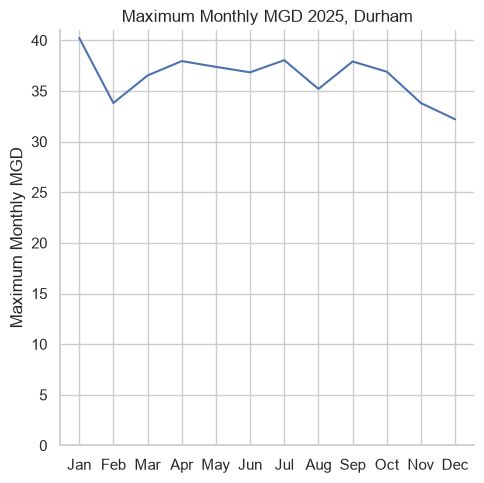

In [13]:
# 2.4 Plot the data
df_use['month_abb'] = pd.Categorical(
    values=df_use['Date'].dt.month_name().str[:3],
    categories=calendar.month_abbr[1:]
)

g = sns.relplot(
    data=df_use,
    x='month_abb',
    y='Max_MGD',
    kind='line',
).set(
    xlabel='',
    ylabel='Maximum Monthly MGD',
    title='Maximum Monthly MGD 2025, Durham',
    ybound=(0,41)
)

## 3. Automating the Scraping Process
### 3.1 Construct the scraping function
Note that the PWSID and the year appear in the web address for the page we scraped. Construct a function with two inputs, "PWSID" and "year", that:
  - Creates a URL pointing to the LWSP for that PWSID for the given year
  - Creates a website object and scrapes the data from that object (just as you did above)
  - Constructs a dataframe from the scraped data, mostly as you did above, but includes the PWSID and year provided as function inputs in the dataframe. 
  - Returns the dataframe as the function's output

In [9]:
# 3.1 Create a scraping function
def scrape_use(the_year, the_PWSID, pause=0):
    url = f'https://www.ncwater.org/WUDC/app/LWSP/report.php?pwsid={the_PWSID}&year={the_year}'
    response = requests.get(url)
    response.raise_for_status()
    the_website = BeautifulSoup(response.text, 'html.parser')

    the_water_system = the_website.select_one('div+ table tr:nth-child(1) td:nth-child(2)').get_text(strip=True)
    the_contact_person = the_website.select_one('div+ table tr:nth-child(4) td:nth-child(2)').get_text(strip=True)
    the_ownership = the_website.select_one('div+ table tr:nth-child(2) td:nth-child(4)').get_text(strip=True)
    the_mgd = [x.get_text(strip=True) for x in the_website.select('th~ td+ td')]

    month_order = [1, 5, 9, 2, 6, 10, 3, 7, 11, 4, 8, 12]
    df = pd.DataFrame({
        'Month':month_order,
        'Year':the_year,
        'PWSID':the_PWSID,
        'Water_System':the_water_system,
        'Contact_Person':the_contact_person,
        'Ownership':the_ownership,
        "Max_MGD":pd.to_numeric(the_mgd),
    })
    df["Date"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))
    df = df.sort_values("Date").reset_index(drop=True)

    if pause: time.sleep(pause)

    return df

### 3.2 Fetch and plot data for Durham (PWSID=`03-32-010`) in 2020
* Use the function above to extract and plot max daily withdrawals for Durham (PWSID=`03-32-010`) for each month in 2020.
* Reveal the structure of your dataframe using the `info()` function. 
* Then create plot your data in a line plot as above: Max Usage by Month.

In [10]:
# 3.2.1 Scrape data for 03-32-010 in 2020 & display its structure
mgd_durham2020 = scrape_use(2020, '03-32-010')
mgd_durham2020.info()
mgd_durham2020

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Month           12 non-null     int64         
 1   Year            12 non-null     int64         
 2   PWSID           12 non-null     str           
 3   Water_System    12 non-null     str           
 4   Contact_Person  12 non-null     str           
 5   Ownership       12 non-null     str           
 6   Max_MGD         12 non-null     float64       
 7   Date            12 non-null     datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 900.0 bytes


,Month,Year,PWSID,Water_System,Contact_Person,Ownership,Max_MGD,Date
0,1,2020,03-32-010,Durham,Kieu Tran,Municipality,36.01,2020-01-01
1,2,2020,03-32-010,Durham,Kieu Tran,Municipality,32.05,2020-02-01
2,3,2020,03-32-010,Durham,Kieu Tran,Municipality,37.29,2020-03-01
3,4,2020,03-32-010,Durham,Kieu Tran,Municipality,32.37,2020-04-01
4,5,2020,03-32-010,Durham,Kieu Tran,Municipality,36.98,2020-05-01
5,6,2020,03-32-010,Durham,Kieu Tran,Municipality,40.61,2020-06-01
6,7,2020,03-32-010,Durham,Kieu Tran,Municipality,43.63,2020-07-01
7,8,2020,03-32-010,Durham,Kieu Tran,Municipality,41.93,2020-08-01
8,9,2020,03-32-010,Durham,Kieu Tran,Municipality,41.69,2020-09-01
9,10,2020,03-32-010,Durham,Kieu Tran,Municipality,40.56,2020-10-01


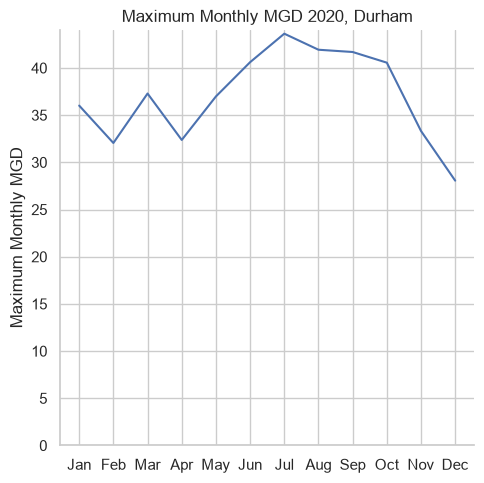

In [12]:
# Plot the data
mgd_durham2020['month_abb'] = pd.Categorical(
    values=df_use['Date'].dt.month_name().str[:3],
    categories=calendar.month_abbr[1:])

g = sns.relplot(
    data=mgd_durham2020,
    x='month_abb',
    y='Max_MGD',
    kind='line',
).set(
    xlabel='',
    ylabel='Maximum Monthly MGD',
    title='Maximum Monthly MGD 2020, Durham',
    ybound=(0,44)
)

### 3.3 Fetch and plot data for Cary (PWSID=`03-92-020`) in 2020

In [17]:
# 3.3.1 Fetch and plot data for Cary (PWSID=`03-92-020`) in 2020
mgd_cary2020 = scrape_use(2020, '03-92-020')
mgd_cary2020.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Month           12 non-null     int64         
 1   Year            12 non-null     int64         
 2   PWSID           12 non-null     str           
 3   Water_System    12 non-null     str           
 4   Contact_Person  12 non-null     str           
 5   Ownership       12 non-null     str           
 6   Max_MGD         12 non-null     float64       
 7   Date            12 non-null     datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 900.0 bytes


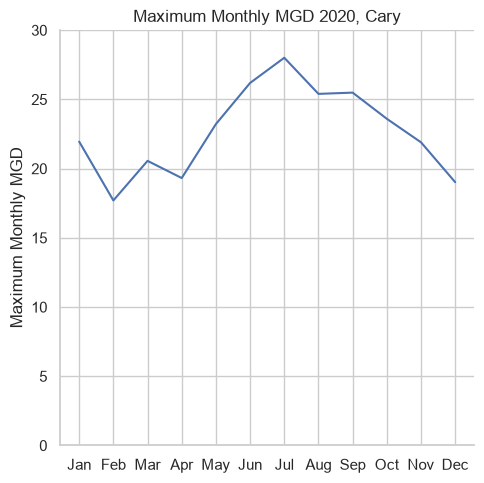

In [19]:
# 3.3.2 Plot the Cary data
mgd_cary2020['month_abb'] = pd.Categorical(
    values=df_use['Date'].dt.month_name().str[:3],
    categories=calendar.month_abbr[1:])

g = sns.relplot(
    data=mgd_cary2020,
    x='month_abb',
    y='Max_MGD',
    kind='line',
).set(
    xlabel='',
    ylabel='Maximum Monthly MGD',
    title='Maximum Monthly MGD 2020, Cary',
    ybound=(0,30)
)

### 3.4 Examine monthy max discharge from 2020-2025
* Use list comprehension (or other methods) to produce a list of dataframes, one for each year in 2020 to 2025
* Concatenate these dataframes into a single one including data for all years
* Create a line plot of max monthly discharge across the full timespan (x-axis labels do not have to be months)

In [21]:
# 3.4.1 Generate a list of the dataframes
list_discharges = []

years = [2020, 2021, 2022, 2023, 2024, 2025]
for year in years:
    list_discharges.append(scrape_use(year, '03-32-010'))

# 3.4.2 Combine them into a single dataframe
df_discharges = pd.concat(list_discharges, ignore_index=True)
df_discharges

,Month,Year,PWSID,Water_System,Contact_Person,Ownership,Max_MGD,Date
0,1,2020,03-32-010,Durham,Kieu Tran,Municipality,36.01,2020-01-01
1,2,2020,03-32-010,Durham,Kieu Tran,Municipality,32.05,2020-02-01
2,3,2020,03-32-010,Durham,Kieu Tran,Municipality,37.29,2020-03-01
3,4,2020,03-32-010,Durham,Kieu Tran,Municipality,32.37,2020-04-01
4,5,2020,03-32-010,Durham,Kieu Tran,Municipality,36.98,2020-05-01
...,...,...,...,...,...,...,...,...
67,8,2025,03-32-010,Durham,Kieu Tran,Municipality,35.20,2025-08-01
68,9,2025,03-32-010,Durham,Kieu Tran,Municipality,37.91,2025-09-01
69,10,2025,03-32-010,Durham,Kieu Tran,Municipality,36.90,2025-10-01
70,11,2025,03-32-010,Durham,Kieu Tran,Municipality,33.80,2025-11-01


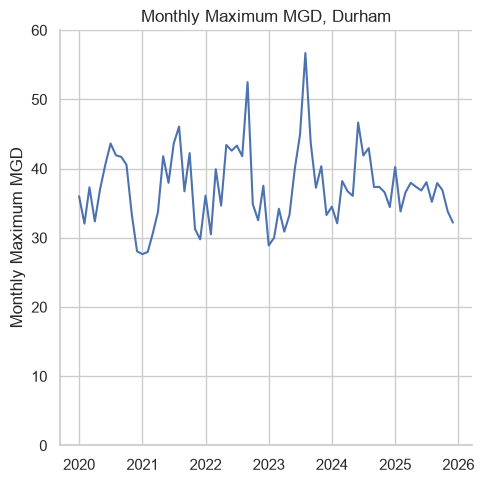

In [22]:
# 3.4.3 Plot
g = sns.relplot(
    data=df_discharges,
    x='Date',
    y='Max_MGD',
    kind='line'
).set(
    xlabel='',
    ylabel= 'Monthly Maximum MGD',
    title='Monthly Maximum MGD, Durham',
    ybound=(0,60)
)